## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

def reconstruct_with_given_kernel_params(X, kernel_params):

    x_input = torch.tensor(X).float()
    
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    plt.plot(z_mu[0].detach(),'o')
    plt.gca().set_prop_cycle(None)
    
    # Update kernel_params
    kernel_params = torch.tensor(kernel_params).reshape(1,1,4).repeat(z_mu.shape[0],z_mu.shape[2],1)
    
    # Correct with GP
    z_star = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params)

    plt.plot(z_star[0].detach())

    plt.show()

    
    # Reconstruct and compute reconstruction error
    x_recon = gpvae.model.backbone.decode(z_star).mean

    x_input[x_input==0] = torch.nan

    return x_input, x_recon

## Generate latent time series of size n_dimensions

In [5]:
# Parameters
n_groups = 1
n_observations_per_group = 5000
n_dimensions = 10
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

100%|██████████████████████████████████████| 5000/5000 [00:06<00:00, 768.18it/s]


## Project this time series into a random space of size n_new_dims

In [6]:
n_new_dims = 10
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

## Create an artificially corrupted dataset by imputing a ratio of p_dataset of your dataset

In [9]:
from pygrinder import mcar
# Normalize

p_dataset = .4

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

In [60]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

latent_size = 30

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = latent_size, #desired latent size, chosen as bigger thant the actual latent space of size 10
            epochs = 200, 
            batch_size = 64,
            beta = 1., #beta weight which is redefined underneath for clarity
            K = 5,  # number of samples from the latent distribution 
            encoder_sizes = (128,64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam() #lr = 1e-4
            )

gpvae.model.backbone.alpha = 1e1   # weight of KL between q(z|x_observed) et q(z|x_observed_corrompu)
gpvae.model.backbone.beta = 1e-5       # weight of prior on latent space (c'est juste une regularisation, je force l'espace latent a etre centré en 0)
gpvae.model.backbone.gamma = 1e-10   # weight of time coherence loss (2 consecutive latent observations z_t and z_{t+1} must be close modulo
                                    # the difference between the observed data X_t and X_{t+1} and the latent variance
gpvae.model.backbone.sampling = True # wether or not we add a sampling scheme to approximate x_missing|x_observed to force
                                     # encode the imputed sample x_sampled = (x_missing|x_observed, x_observed) such that
                                     # q(z|x_sampled) to be included in q(z|x_observed)

#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2024-12-17 17:37:53 [INFO]: No given device, using default device: cpu
2024-12-17 17:37:53 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-12-17 17:37:53 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 19,458


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=30, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=30, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


2024-12-17 17:38:02 [INFO]: Epoch 001 - training loss: 43.8761, validation loss: 0.2951
2024-12-17 17:38:10 [INFO]: Epoch 002 - training loss: 19.8027, validation loss: 0.2357
2024-12-17 17:38:18 [INFO]: Epoch 003 - training loss: 23.5116, validation loss: 0.2260
2024-12-17 17:38:27 [INFO]: Epoch 004 - training loss: 24.4136, validation loss: 0.2028
2024-12-17 17:38:34 [INFO]: Epoch 005 - training loss: 22.2101, validation loss: 0.1848
2024-12-17 17:38:42 [INFO]: Epoch 006 - training loss: 21.3038, validation loss: 0.1686
2024-12-17 17:38:50 [INFO]: Epoch 007 - training loss: 20.8810, validation loss: 0.1585
2024-12-17 17:39:04 [INFO]: Epoch 008 - training loss: 20.3141, validation loss: 0.1511
2024-12-17 17:39:13 [INFO]: Epoch 009 - training loss: 19.9566, validation loss: 0.1416
2024-12-17 17:39:21 [INFO]: Epoch 010 - training loss: 19.6419, validation loss: 0.1348


plotting


2024-12-17 17:39:31 [INFO]: Epoch 011 - training loss: 19.3861, validation loss: 0.1292
2024-12-17 17:39:39 [INFO]: Epoch 012 - training loss: 19.2468, validation loss: 0.1243
2024-12-17 17:39:48 [INFO]: Epoch 013 - training loss: 19.0592, validation loss: 0.1212
2024-12-17 17:39:57 [INFO]: Epoch 014 - training loss: 18.9548, validation loss: 0.1185
2024-12-17 17:40:06 [INFO]: Epoch 015 - training loss: 18.6966, validation loss: 0.1138
2024-12-17 17:40:15 [INFO]: Epoch 016 - training loss: 18.4829, validation loss: 0.1102
2024-12-17 17:40:23 [INFO]: Epoch 017 - training loss: 18.3011, validation loss: 0.1075
2024-12-17 17:40:32 [INFO]: Epoch 018 - training loss: 18.2913, validation loss: 0.1065
2024-12-17 17:40:41 [INFO]: Epoch 019 - training loss: 18.1926, validation loss: 0.1053
2024-12-17 17:40:49 [INFO]: Epoch 020 - training loss: 18.2097, validation loss: 0.1042


...

2024-12-17 17:59:11 [INFO]: Epoch 163 - training loss: 25.9133, validation loss: 0.0939
2024-12-17 17:59:20 [INFO]: Epoch 164 - training loss: 25.9638, validation loss: 0.0977
2024-12-17 17:59:29 [INFO]: Epoch 165 - training loss: 25.9289, validation loss: 0.0956
2024-12-17 17:59:38 [INFO]: Epoch 166 - training loss: 26.1200, validation loss: 0.1006
2024-12-17 17:59:48 [INFO]: Epoch 167 - training loss: 26.0739, validation loss: 0.0955
2024-12-17 17:59:57 [INFO]: Epoch 168 - training loss: 26.1440, validation loss: 0.0966
2024-12-17 18:00:05 [INFO]: Epoch 169 - training loss: 26.2447, validation loss: 0.0964
2024-12-17 18:00:13 [INFO]: Epoch 170 - training loss: 26.3107, validation loss: 0.0955
2024-12-17 18:00:25 [INFO]: Epoch 171 - training loss: 26.4336, validation loss: 0.0982
2024-12-17 18:00:33 [INFO]: Epoch 172 - training loss: 26.4698, validation loss: 0.0961


plotting


2024-12-17 18:00:42 [INFO]: Epoch 173 - training loss: 26.5174, validation loss: 0.0992
2024-12-17 18:00:49 [INFO]: Epoch 174 - training loss: 26.5696, validation loss: 0.0983
2024-12-17 18:00:57 [INFO]: Epoch 175 - training loss: 26.5527, validation loss: 0.0970
2024-12-17 18:01:05 [INFO]: Epoch 176 - training loss: 26.6619, validation loss: 0.0966
2024-12-17 18:01:12 [INFO]: Epoch 177 - training loss: 26.6731, validation loss: 0.0967
2024-12-17 18:01:21 [INFO]: Epoch 178 - training loss: 26.6677, validation loss: 0.0954
2024-12-17 18:01:28 [INFO]: Epoch 179 - training loss: 26.7101, validation loss: 0.0955
2024-12-17 18:01:35 [INFO]: Epoch 180 - training loss: 26.7665, validation loss: 0.0961
2024-12-17 18:01:42 [INFO]: Epoch 181 - training loss: 26.8097, validation loss: 0.0964
2024-12-17 18:01:49 [INFO]: Epoch 182 - training loss: 26.8734, validation loss: 0.0981


plotting


2024-12-17 18:01:57 [INFO]: Epoch 183 - training loss: 26.8866, validation loss: 0.0986
2024-12-17 18:02:04 [INFO]: Epoch 184 - training loss: 26.9282, validation loss: 0.0963
2024-12-17 18:02:13 [INFO]: Epoch 185 - training loss: 26.9961, validation loss: 0.1000
2024-12-17 18:02:21 [INFO]: Epoch 186 - training loss: 26.9680, validation loss: 0.1020
2024-12-17 18:02:30 [INFO]: Epoch 187 - training loss: 26.9182, validation loss: 0.0973
2024-12-17 18:02:39 [INFO]: Epoch 188 - training loss: 27.0278, validation loss: 0.0964
2024-12-17 18:02:47 [INFO]: Epoch 189 - training loss: 27.0255, validation loss: 0.0991
2024-12-17 18:02:55 [INFO]: Epoch 190 - training loss: 27.0687, validation loss: 0.0960
2024-12-17 18:03:02 [INFO]: Epoch 191 - training loss: 27.1159, validation loss: 0.0992
2024-12-17 18:03:06 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-12-17 18:03:06 [INFO]: Finished training. The best model is from epoch#71.


In [54]:
for i,param in enumerate(gpvae.model.backbone.decoder.parameters()):
    if i!=0:
        param.requires_grad = False
for i,param in enumerate(gpvae.model.backbone.encoder.parameters()):
    if i<=5:
        param.requires_grad = False
gpvae.model.backbone.alpha = 1e1
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

plotting


2024-12-17 17:01:24 [INFO]: Epoch 001 - training loss: 16.2922, validation loss: 0.1831
2024-12-17 17:01:25 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-12-17 17:01:25 [INFO]: Finished training. The best model is from epoch#1.


In [709]:
# save and load 
torch.save(gpvae, f'gvpae_p_dataset_{p_dataset}-a_{alpha}_b_{beta}_gamma_{gamma}')
gpvae = torch.load(f'gvpae_p_dataset_{p_dataset}-a_{alpha}_b_{beta}_gamma_{gamma}')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/2774675125.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvae = torch.load(f'gvpae_p_dataset_{p_datas

## Observe sampled reconstructions

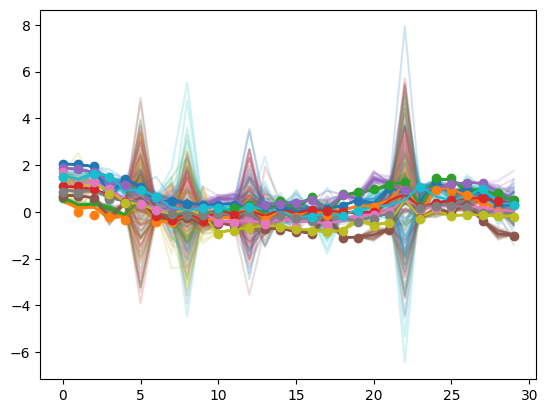

In [61]:
import torch

n_samples = 30
i = 1

qz_x = gpvae.model.backbone.encode(torch.tensor(X[:10]).float())
for _ in range(n_samples):
    z = qz_x.rsample()
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
    plt.plot(X_recon[i], label = 'reconstruction', alpha = .2)
    plt.gca().set_prop_cycle(None)
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[i], label = 'mean reconstruction')
plt.gca().set_prop_cycle(None)
X_0 = np.copy(X[i])
X_0[X_0==0] = np.nan
plt.plot(X_0,'o', label = 'Input')
plt.show();

In [62]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
#gpvae.gp.p = 0.1 # ratio of imputation of the dataset
gpvae.fit_kernel(dataset_train)  # train the model to learn the kernel parameters

fitting kernel


Epoch 1/20: 55it [00:37,  1.47it/s]


Epoch 1/20: Average Loss = 0.043797


Epoch 2/20: 55it [00:33,  1.63it/s]


Epoch 2/20: Average Loss = 0.044088


Epoch 3/20: 55it [00:33,  1.63it/s]


Epoch 3/20: Average Loss = 0.045423


Epoch 4/20: 5it [00:03,  1.48it/s]


KeyboardInterrupt: 

## Visualisation: embed the first 10 time series, use the GP scheme to correct, and plot reconstruction

In [63]:
X_torch = torch.tensor(X).float()[:10]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)
X_recon = gpvae.model.backbone.decode(embedding.mean).mean

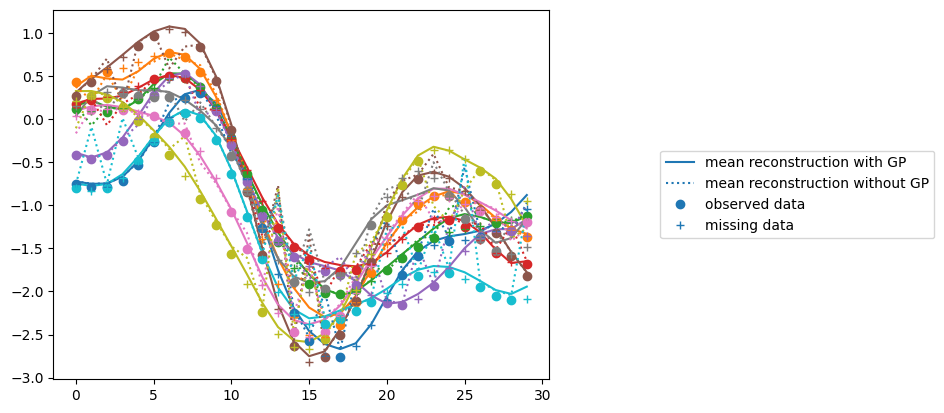

In [64]:
i = 2 ## reconstruct time series number i
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach())
plt.plot([], label = 'mean reconstruction with GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':')
plt.plot([], ':', label = 'mean reconstruction without GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o');
plt.plot([], 'o', label = 'observed data')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+');
plt.plot([], '+', label = 'missing data')
plt.legend(bbox_to_anchor=[1.5, 0.5], 
           loc='center')